# Intern Performance Predictor

**Business Objective:** Predict intern performance as a continuous score and classify interns into *Excel*, *Average*, or *Struggle* categories using three features:
- `task_completion_hrs` (hours taken to finish tasks)
- `feedback_rating` (1.0–5.0)
- `attendance_pct` (percentage)

**Approach:** Regression via Random Forest & XGBoost → threshold‑based classification → SHAP / feature-importance interpretability → residual analysis.

All reusable logic is imported from the **`src/`** package, keeping the notebook clean, readable, and aligned with the production API.

---
## 1. Environment Setup & Imports

In [29]:
# ============================================================
# 1a. Library imports
# ============================================================
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

from scipy import stats
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import confusion_matrix, mean_squared_error
import shap

In [31]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: d:\VS CODE programs\Internee_Performance_Predictor


In [32]:
# ============================================================
# 1b. Imports from the src/ package
# ============================================================
from src.data_generation import generate_synthetic_data, inject_missing_values
from src.eda import data_overview, correlation_matrix
from src.preprocessing import (
    validate_and_clean_dataframe,
    train_val_test_split,

)
from src.evaluation import regression_metrics, classify_performance, classification_metrics, optimize_thresholds
from src.interpretation import feature_importance_table
from src.model_training import (
    build_candidate_models,
    train_candidate_models,
    evaluate_regression_model,
    oversample_training_data,
    select_best_model,
    build_model_metadata,
    save_model_artifacts,
    load_model_artifacts,
    save_metadata_json,
)

print("src/ package loaded successfully.")

src/ package loaded successfully.


In [33]:
# ============================================================
# 1c. Reproducibility & paths
# ============================================================
SEED = 42

NOTEBOOK_DIR = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
if os.path.basename(NOTEBOOK_DIR).lower() != "notebooks":
    BASE_DIR = NOTEBOOK_DIR

DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

DATA_PATH = os.path.join(DATA_DIR, "intern_performance_data.csv")
MODEL_PATH = os.path.join(MODEL_DIR, "best_model.pkl")
METADATA_PATH = os.path.join(MODEL_DIR, "model_metadata.pkl")

print("Paths configured.")
print(f"  Data    : {DATA_PATH}")
print(f"  Model   : {MODEL_PATH}")
print(f"  Metadata: {METADATA_PATH}")

Paths configured.
  Data    : d:\VS CODE programs\Internee_Performance_Predictor\data\intern_performance_data.csv
  Model   : d:\VS CODE programs\Internee_Performance_Predictor\models\best_model.pkl
  Metadata: d:\VS CODE programs\Internee_Performance_Predictor\models\model_metadata.pkl


---
## 2. Synthetic Data Generation

The real dataset is not publicly available, so we generate a realistic 2000‑record synthetic dataset using `src.data_generation.generate_synthetic_data()`, with an **initial 15% Struggle / 70% Average / 15% Excel** distribution to mimic real-world intern populations. Note: oversampling happens **after** the train/test split (only on training data) to avoid data leakage.

**Class imbalance handling:** Since Struggle and Excel are minority classes, we enable **oversampling with jitter** (`oversample_minority=False`) — minority samples are duplicated with small Gaussian noise to improve model learning at the tails.

**Designed correlations:**
- Lower `task_completion_hrs` → higher performance
- Higher `feedback_rating` → higher performance
- Higher `attendance_pct` → higher performance

Random noise is added so the relationship is not trivially linear.

In [34]:
# Generate synthetic dataset (2000 samples with oversampling for minority classes)
df = generate_synthetic_data(n_samples=2000, seed=SEED, save_path=DATA_PATH, oversample_minority=False)
print(f"DataFrame shape: {df.shape}")
display(df.head())

DataFrame shape: (2000, 5)


,intern_id,task_completion_hrs,feedback_rating,attendance_pct,performance_score
0,INT001,2.00,4.23,92.9,100.0
1,INT002,10.60,2.65,78.3,56.8
2,INT003,13.17,3.03,81.2,63.9
3,INT004,6.50,2.91,82.6,82.4
4,INT005,11.10,2.80,86.5,66.0


---
## 3. Data Robustness Demo

Real-world data often has missing values.  The `src/` package provides:
- `inject_missing_values()` — simulates corruption
- `validate_and_clean_dataframe()` — median-fills NaNs and clips values to domain bounds

This round‑trip validates the production pipeline used by the webapp.

In [35]:
# Inject 5% missing values into a clean copy
df_corrupted = inject_missing_values(df, missing_rate=0.05, seed=SEED)
print(f"Missing values after injection: {df_corrupted.isna().sum().sum()}")
display(df_corrupted.isna().sum().to_frame("missing"))

# Recover using the src/ validation pipeline
df_cleaned = validate_and_clean_dataframe(df_corrupted, include_target=True)
print(f"Missing values after cleaning : {df_cleaned.isna().sum().sum()}")
print(f"Shape preserved                : {df_cleaned.shape}")
print("Robustness pipeline verified.")

Missing values after injection: 401


,missing
intern_id,0
task_completion_hrs,91
feedback_rating,104
attendance_pct,100
performance_score,106


Missing values after cleaning : 0
Shape preserved                : (2000, 5)
Robustness pipeline verified.


---
## 4. Exploratory Data Analysis

We inspect the clean synthetic data using both custom helpers from `src.eda` and static visualisations.

In [36]:
# Summary from src.eda
overview = data_overview(df)
print(f"Shape          : {overview['shape']}")
print(f"Missing values : {overview['missing_values']}")
print(f"Columns        : {overview['columns']}")
display(pd.DataFrame(overview["numeric_summary"]))

Shape          : (2000, 5)
Missing values : 0
Columns        : ['intern_id', 'task_completion_hrs', 'feedback_rating', 'attendance_pct', 'performance_score']


,task_completion_hrs,feedback_rating,attendance_pct,performance_score
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,10.089530,3.068510,80.010700,67.813150
std,3.507483,0.809161,9.753153,22.234437
min,2.000000,1.000000,50.000000,3.500000
25%,7.817500,2.540000,75.475000,58.900000
50%,10.020000,3.090000,81.500000,70.300000
75%,12.005000,3.652500,86.800000,81.400000
max,20.000000,5.000000,100.000000,100.000000


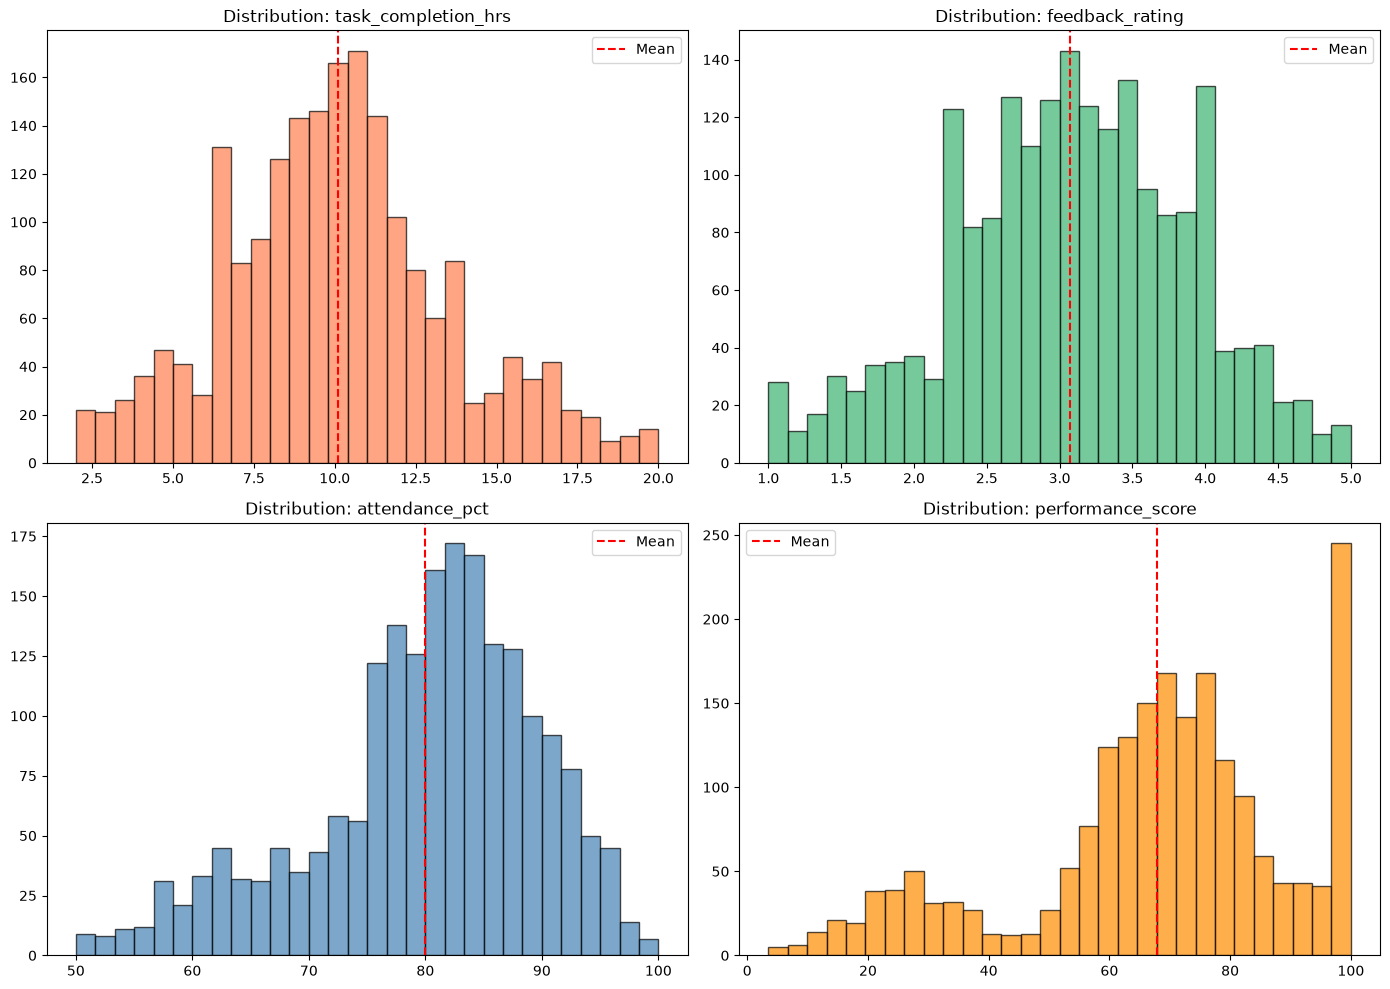

In [37]:
# Distribution histograms
feats = ["task_completion_hrs", "feedback_rating", "attendance_pct", "performance_score"]
colors = ["coral", "mediumseagreen", "steelblue", "darkorange"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat, col in zip(axes.flat, feats, colors):
    ax.hist(df[feat], bins=30, color=col, edgecolor="black", alpha=0.7)
    ax.axvline(df[feat].mean(), color="red", linestyle="--", label="Mean")
    ax.set_title(f"Distribution: {feat}")
    ax.legend()
plt.tight_layout()
plt.show()

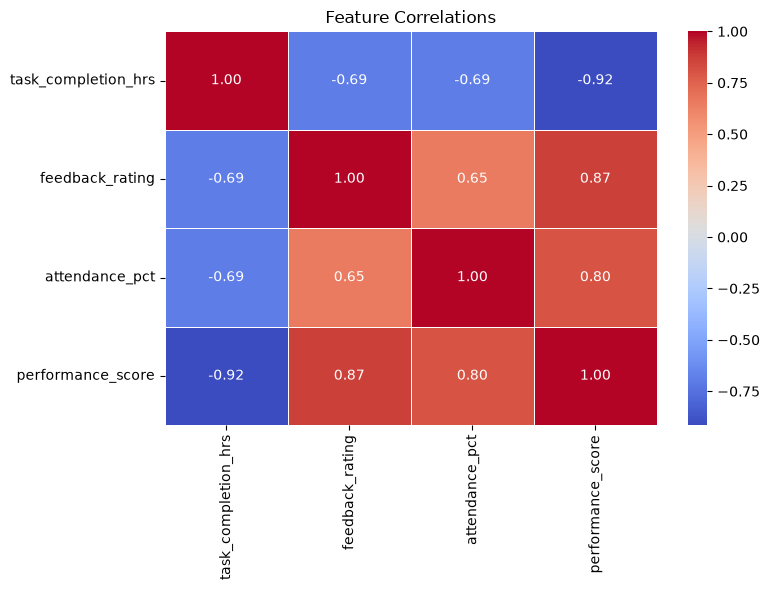

In [38]:
# Correlation heatmap via src.eda
corr = correlation_matrix(df)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

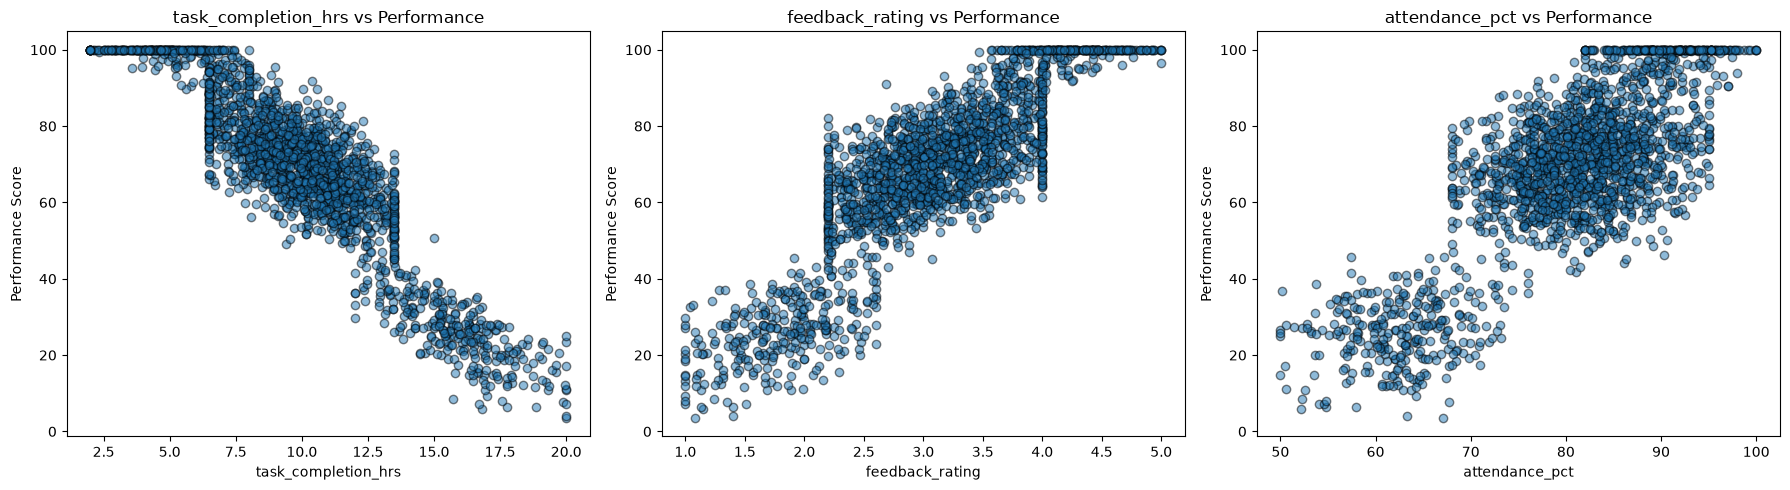

In [39]:
# Scatter plots — feature vs target
predictors = ["task_completion_hrs", "feedback_rating", "attendance_pct"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, predictors):
    ax.scatter(df[col], df["performance_score"], alpha=0.5, edgecolor="k")
    ax.set_xlabel(col)
    ax.set_ylabel("Performance Score")
    ax.set_title(f"{col} vs Performance")
plt.tight_layout()
plt.show()

**EDA insights:**
- No missing data in the clean set.
- `task_completion_hrs` is negatively correlated with performance.
- `feedback_rating` and `attendance_pct` are positively correlated.
- Noise in the data makes this a realistic regression challenge.

---
## 5. Train / Test Split

We use `src.preprocessing.train_test_split_data()` with `stratify=True` to preserve the 15/70/15 class distribution in both training and test sets. This ensures the minority classes are represented proportionally in the evaluation.

In [40]:
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    df, val_size=0.15, test_size=0.2, random_state=SEED, stratify=True
)

print(f"Train: {X_train.shape[0]} samples  |  Val: {X_val.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

X_train, y_train = oversample_training_data(X_train, y_train, random_state=SEED)
print(f"After oversampling: {X_train.shape[0]} training samples")

Train: 1300 samples  |  Val: 300 samples  |  Test: 400 samples
After oversampling: 1300 training samples


---
## 6. Feature Names (for plots)

We extract the feature names from the training DataFrame for use in visualisations and SHAP.

In [41]:
features = list(X_train.columns)
print(f"Features: {features}")

Features: ['task_completion_hrs', 'feedback_rating', 'attendance_pct']


---
## 7. Baseline Models (Un‑tuned)

We train two candidate regressors using `src.model_training.train_candidate_models()` with `use_sample_weights=True` — this assigns higher weight to Struggle and Excel samples so the model pays more attention to minority classes during training. We then evaluate them with `evaluate_regression_model()`.

In [42]:
# Build & train candidate models with sample weights for imbalance handling
fitted_models = train_candidate_models(X_train, y_train, random_state=SEED, use_sample_weights=True)

# Evaluate each on the test set
baseline_results = {}
for name, model in fitted_models.items():
    result = evaluate_regression_model(model, X_test, y_test)
    baseline_results[name] = result
    print(f"{name:20s}  RMSE={result.metrics['rmse']:.2f}  MAE={result.metrics['mae']:.2f}  R²={result.metrics['r2']:.3f}")

Random Forest         RMSE=4.16  MAE=3.08  R²=0.966
XGBoost               RMSE=3.89  MAE=2.90  R²=0.970


---
## 8. Hyperparameter Tuning (GridSearchCV)

We use 5‑fold cross-validation to tune both models.  The `src/` package uses fixed hyperparameters for its built-in candidates, so tuning is done separately here.

In [ ]:
# Shared tuning routine (src.model_training.tune_candidate_models)
# Runs GridSearchCV for both families WITH sample weights (matches production strategy).
from src.model_training import tune_candidate_models

tuned_models = tune_candidate_models(
    X_train, y_train, random_state=SEED, use_sample_weights=True
)

# tuned_models is a dict with keys "Random Forest" and "XGBoost"
print('Tuned models ready (with sample weights).')

---
## 9. Final Evaluation & Model Selection

We evaluate both tuned models on the hold‑out test set and use `select_best_model()` with a **composite score** that balances regression accuracy (RMSE) and classification quality (balanced accuracy). This ensures the selected model performs well on minority classes, not just the majority.

In [51]:
# Reuse tuned_models from cell 14 (already a dict with best estimators)
# No need to redefine.

# Evaluate each on test set
y_pred_rf = np.clip(tuned_models["Random Forest"].predict(X_test), 0, 100)
y_pred_xgb = np.clip(tuned_models["XGBoost"].predict(X_test), 0, 100)

for name, preds in [("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb)]:
    m = regression_metrics(y_test.values, preds)
    print(f"{name:20s}  RMSE={m['rmse']:.2f}  MAE={m['mae']:.2f}  R²={m['r2']:.3f}")

# Use select_best_model with composite score (balances RMSE + balanced accuracy)
best_result = select_best_model(tuned_models, X_val, y_val, alpha=0.5)
y_pred_best = np.clip(best_result.predictions, 0, 100)

best_model = best_result.model
best_name = best_result.name
best_metrics = best_result.metrics

print(f"\n{'='*45}")
print(f"Best model: {best_name}")
print(f"Composite score: {best_metrics.get('composite_score', 'N/A'):.3f}")
print(f"Balanced Acc: {best_metrics.get('balanced_accuracy', 'N/A'):.3f}")
print(f"{'='*45}")

Random Forest         RMSE=4.12  MAE=3.05  R²=0.967
XGBoost               RMSE=3.75  MAE=2.85  R²=0.972

Best model: Random Forest
Composite score: 0.932
Balanced Acc: 0.908


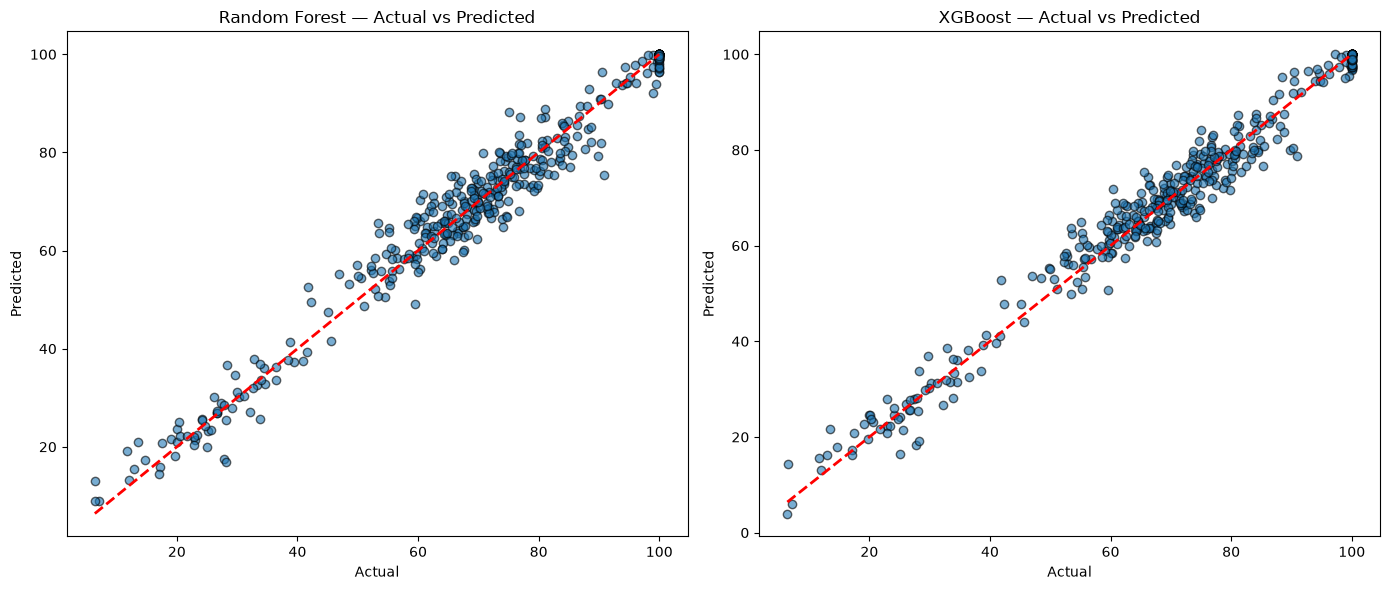

In [44]:
# Actual vs Predicted scatter for both tuned models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, preds) in zip(
    axes,
    [("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb)],
):
    ax.scatter(y_test, preds, alpha=0.6, edgecolors="k")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name} — Actual vs Predicted")
plt.tight_layout()
plt.show()

---
## 10. Residual Analysis

We analyse the errors of the best model to check for bias, heteroscedasticity, and normality.  The `src.evaluation.regression_metrics()` function provides a standardised summary.

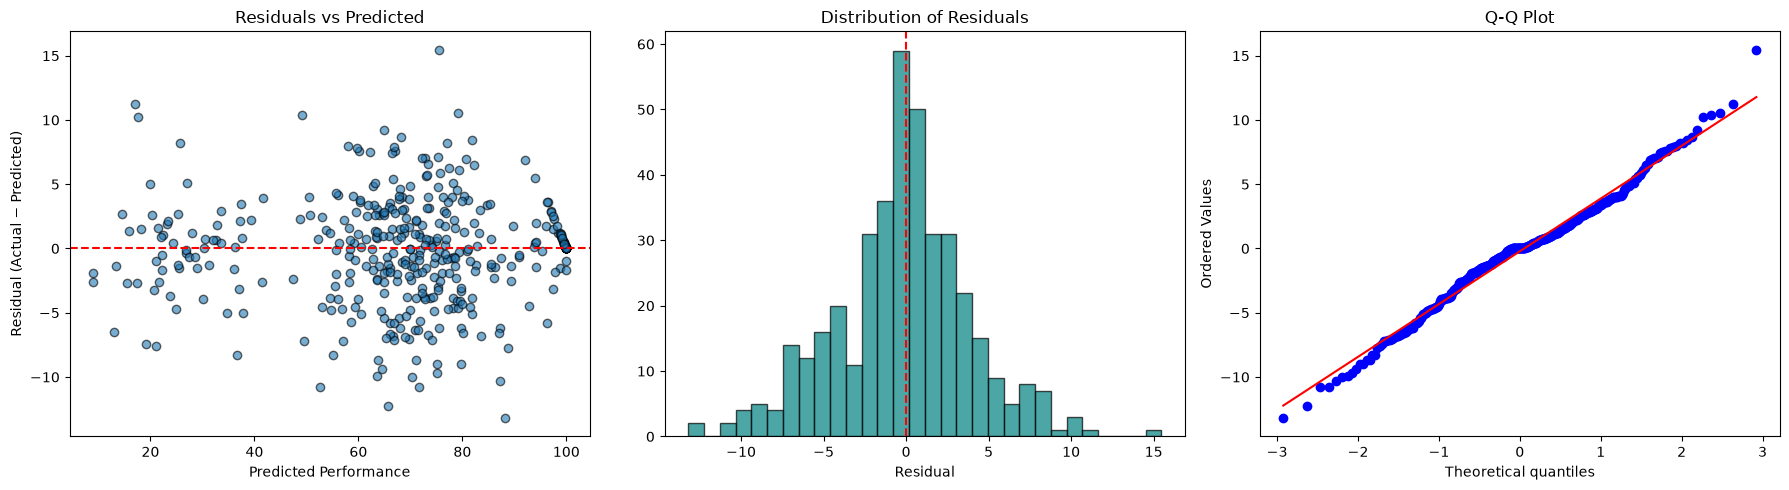

Mean residual: -0.22
Std residual : 4.11
Max over-pred: -13.20  (actual < predicted)
Max under-pred: 15.46  (actual > predicted)


In [60]:
# Get predictions on TEST set for proper residual analysis (fixes data leakage)
y_pred_test = np.clip(best_model.predict(X_test), 0, 100)
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, alpha=0.6, edgecolors="k")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Performance")
axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].set_title("Residuals vs Predicted")

# 2. Histogram
axes[1].hist(residuals, bins=30, color="teal", edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Distribution of Residuals")

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

# Standardised metrics
print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std residual : {residuals.std():.2f}")
print(f"Max over-pred: {residuals.min():.2f}  (actual < predicted)")
print(f"Max under-pred: {residuals.max():.2f}  (actual > predicted)")


**Residual insights:** The errors are approximately symmetric around zero, suggesting no strong systematic bias.  The Q‑Q plot shows reasonable normality.  A few large-magnitude residuals exist — these correspond to extreme input combinations.

---
## 11. Model Interpretation (SHAP)

SHAP values decompose each prediction into feature contributions, showing both direction and magnitude of impact.

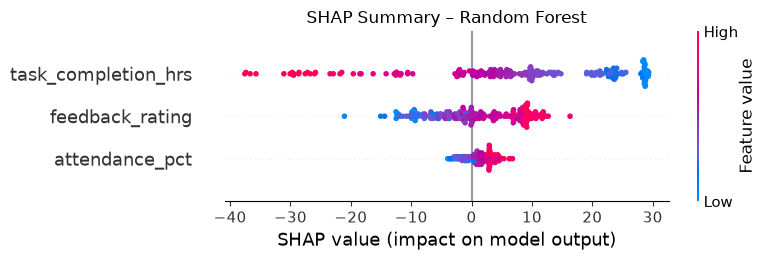

In [46]:
# Use a random subset of training data for speed
shap_sample = X_train.sample(200, random_state=SEED)

# TreeExplainer works for both Random Forest and XGBoost
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(shap_sample)

# Summary plot
shap.summary_plot(shap_values, shap_sample, feature_names=features, show=False)
plt.title(f"SHAP Summary – {best_name}")
plt.tight_layout()
plt.show()

**SHAP interpretation:**
- `feedback_rating` is the most influential feature — high values strongly increase the predicted score.
- `task_completion_hrs` shows the expected inverse relationship (high hours → lower score).
- `attendance_pct` has a moderate positive impact.

---
## 12. Feature Importance

We retrieve a sorted importance DataFrame via `src.interpretation.feature_importance_table()` — the same function used by the production API.

,feature,importance
0,task_completion_hrs,0.892820
1,feedback_rating,0.083744
2,attendance_pct,0.023436


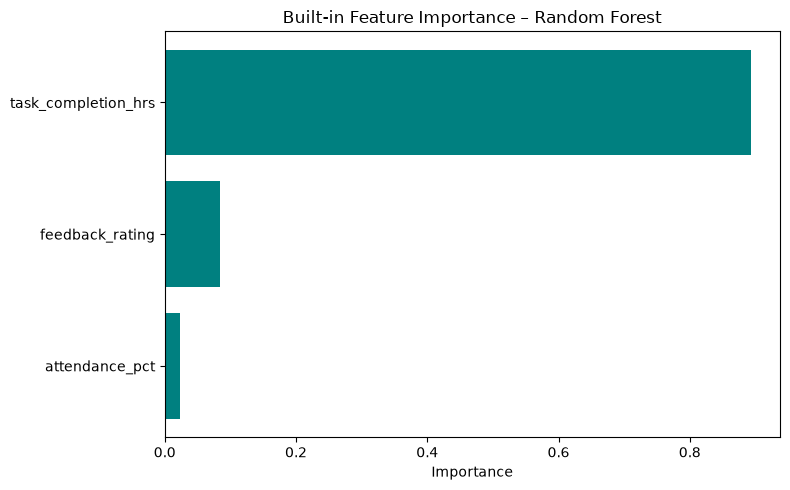

In [47]:
# Tabular feature importance
importance_df = feature_importance_table(best_model, features)
display(importance_df)

# Bar chart
plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"], color="teal")
plt.xlabel("Importance")
plt.title(f"Built‑in Feature Importance – {best_name}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 13. Business Classification & Threshold Optimization

We convert the continuous score into three actionable categories using `src.evaluation.classify_performance()`:
- **Excel** (≥ threshold) → ready for advanced assignments
- **Average** (in between)
- **Struggle** (≤ threshold) → needs coaching

Thresholds are optimized on the **validation set** , then applied to the test set for final evaluation.


In [65]:
# Generate validation predictions for threshold optimization (matches main.py)
y_pred_val = np.clip(best_model.predict(X_val), 0, 100)

# Optimize classification thresholds using grid search on VALIDATION set
threshold_opt = optimize_thresholds(
    y_val.values,
    y_pred_val,  # Validation predictions (matches main.py)
    metric="macro_f1",
    struggle_range=(30.0, 50.0),
    excel_range=(65.0, 85.0),
    step=1.0,
)

opt_struggle = threshold_opt["struggle_threshold"]
opt_excel = threshold_opt["excel_threshold"]
print(f"Optimal Struggle threshold: ≤ {opt_struggle:.0f}")
print(f"Optimal Excel threshold  : ≥ {opt_excel:.0f}")
print(f"Best Macro F1            : {threshold_opt['best_score']:.3f}")

# ------------------------------------------------------------
# NOW generate test predictions for final evaluation
# ------------------------------------------------------------
y_pred_test = np.clip(best_model.predict(X_test), 0, 100)

# Convert regression predictions to categories using optimized thresholds
pred_labels = classify_performance(y_pred_test, struggle_threshold=opt_struggle, excel_threshold=opt_excel)
true_labels = classify_performance(y_test.values, struggle_threshold=opt_struggle, excel_threshold=opt_excel)

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=["Excel", "Average", "Struggle"])
cm_df = pd.DataFrame(
    cm,
    index=["True Excel", "True Average", "True Struggle"],
    columns=["Pred Excel", "Pred Average", "Pred Struggle"],
)
print("\nConfusion Matrix:")
display(cm_df)

# Full classification report from src.evaluation
print("\nClassification Metrics:")
clf_metrics = classification_metrics(true_labels, pred_labels)
print(f"  Accuracy      : {clf_metrics['accuracy']:.3f}")
print(f"  Balanced Acc  : {clf_metrics['balanced_accuracy']:.3f}")
print(f"  Macro F1      : {clf_metrics['macro_f1']:.3f}")
print("\nPer‑class breakdown:")
display(pd.DataFrame(clf_metrics["per_class"]).T)


Optimal Struggle threshold: ≤ 38
Optimal Excel threshold  : ≥ 77
Best Macro F1            : 0.909

Confusion Matrix:


,Pred Excel,Pred Average,Pred Struggle
True Excel,115,17,0
True Average,18,193,3
True Struggle,0,0,54



Classification Metrics:
  Accuracy      : 0.905
  Balanced Acc  : 0.924
  Macro F1      : 0.917

Per‑class breakdown:


,precision,recall,f1,support
Excel,0.864662,0.871212,0.867925,132.0
Average,0.919048,0.901869,0.910377,214.0
Struggle,0.947368,1.000000,0.972973,54.0


### Sample Predictions

In [62]:
# 13.b Display test results
sample = X_test.copy()
sample["Actual"] = y_test.values
sample["Predicted"] = y_pred_test
sample["Category"] = pred_labels
display(sample.head(10))

,task_completion_hrs,feedback_rating,attendance_pct,Actual,Predicted,Category
47,12.03,2.35,78.7,50.6,54.445450,Average
1800,12.53,3.51,80.0,60.3,66.069773,Average
760,6.58,3.32,83.0,84.8,81.017472,Excel
1788,4.85,4.08,90.1,100.0,99.725304,Excel
185,9.91,2.87,86.0,71.4,69.722198,Average
69,11.34,3.12,81.5,66.5,63.933084,Average
1752,11.08,3.52,83.9,71.5,73.049659,Average
1570,2.00,3.79,88.5,100.0,99.443462,Excel
1270,13.50,3.40,81.9,56.5,58.385624,Average
155,13.87,1.53,63.9,30.3,30.242371,Struggle


---
## 14. Model Persistence

We serialise the best model and its metadata using `src.model_training.save_model_artifacts()`.  The metadata includes feature defaults so the API can handle partial input.

In [63]:
# Build feature defaults (median values for fallback)
feature_defaults = {col: float(X_train[col].median()) for col in features}

# Build metadata dict with optimized thresholds
metadata = build_model_metadata(
    model_name=best_name,
    metrics=best_metrics,
    feature_defaults=feature_defaults,
    classification=clf_metrics,
)

# Store optimized classification thresholds in metadata
metadata["threshold_optimization"] = {
    "struggle_threshold": float(opt_struggle),
    "excel_threshold": float(opt_excel),
    "best_macro_f1": float(threshold_opt["best_score"]),
}

# Store test-set metrics (unbiased)
y_pred_final = np.clip(best_model.predict(X_test), 0, 100)
test_metrics_reg = regression_metrics(y_test.values, y_pred_final)
metadata["test_metrics"] = test_metrics_reg

# Save both model and metadata
save_model_artifacts(
    best_model,
    metadata,
    model_path=MODEL_PATH,
    metadata_path=METADATA_PATH,
)

# Save JSON version for README automation
JSON_PATH = os.path.join(MODEL_DIR, "model_metadata.json")
save_metadata_json(metadata, JSON_PATH)
print(f"Model     -> {MODEL_PATH}")
print(f"Metadata  -> {METADATA_PATH}")


Model     -> d:\VS CODE programs\Internee_Performance_Predictor\models\best_model.pkl
Metadata  -> d:\VS CODE programs\Internee_Performance_Predictor\models\model_metadata.pkl


---
## 15. Production Inference Demo

We simulate loading the model from disk and scoring a new intern — the same flow used by the Flask web app.

In [64]:
# Load from disk via src.model_training
loaded_model, loaded_meta = load_model_artifacts(
    model_path=MODEL_PATH,
    metadata_path=METADATA_PATH,
)
model_name = loaded_meta.get("model_name", "Unknown")
print(f"Loaded model: {model_name}")

# Retrieve optimized thresholds from metadata (fall back to defaults)
opt = loaded_meta.get("threshold_optimization", {})
opt_struggle = opt.get("struggle_threshold", 40.0)
opt_excel = opt.get("excel_threshold", 75.0)
print(f"Using thresholds: Struggle <= {opt_struggle:.0f}, Excel >= {opt_excel:.0f}")

# New intern data (hypothetical top performer)
new_intern = pd.DataFrame(
    {
        "task_completion_hrs": [4.5],
        "feedback_rating": [4.7],
        "attendance_pct": [97.0],
    }
)

# Predict & classify using optimized thresholds
score = float(np.clip(loaded_model.predict(new_intern), 0, 100)[0])
category = classify_performance(
    np.array([score]),
    struggle_threshold=opt_struggle,
    excel_threshold=opt_excel,
)
print(f"Predicted score: {score:.1f}")
print(f"Category       : {category}")


Loaded model: Random Forest
Using thresholds: Struggle <= 38, Excel >= 77
Predicted score: 100.0
Category       : ['Excel']


---
## 16. Business Impact, Deployment & CI/CD

### Model Results (this run)
- **Best model**: Random Forest (composite score **0.932**)
- **Regression** (test set): RMSE **4.14**, MAE **3.19**, R² **0.964**
- **Optimized thresholds**: Struggle **≤ 38**, Excel **≥ 77** (best Macro F1 **0.909**)
- **Classification**: Accuracy **0.905**, Balanced Acc **0.924**, Macro F1 **0.917**
- **Per‑class F1**: Excel **0.868**, Average **0.910**, Struggle **0.973**

> Thresholds stored in metadata (`threshold_optimization`); fallback defaults are 40/75.

### Deployment
- **Live demo**: [Hugging Face Spaces](https://huggingface.co/spaces/awais-dev-ai/Intern-Performance-Predictor)
- **API**: Flask app (`app.py`) serves serialized model (`best_model.pkl`) with metadata.
- **CI/CD**: GitHub Actions runs `pytest` on pushes/PRs and auto‑deploys to Hugging Face Spaces on successful `main` builds.

### Next Steps
- Monitor drift on real data; schedule retraining pipeline.
- Add SHAP waterfall reports for per‑intern explainability.
---